# PM₂.₅ Forecasting with TCN — Toronto Downtown Station

**Research Question:** How accurately can PM₂.₅ concentrations in Ontario be forecasted over **4-hour, 6-hour, and 24-hour** intervals using meteorological data?

**Organisation:** Toronto Transit Commission (TTC)  
**Model:** Multi-horizon Temporal Convolutional Network (TCN)  
**Input:** 24-hour lookback window of weather + air-quality features  
**Outputs:** Predicted PM₂.₅ at +4 h, +6 h, and +24 h

---

## Why TCN instead of LSTM?

| Property | LSTM | TCN |
|---|---|---|
| Gradient flow | Can vanish/explode through long sequences | Direct residual paths, no vanishing gradient |
| Training speed | Sequential (slow) | Fully parallelisable (fast) |
| Receptive field | Implicit, hard to control | Explicit: `(k-1) × Σ 2ⁱ` — 60 steps with 4 blocks |
| Stability | Sensitive to initialisation and LR | BatchNorm + residuals make training robust |

---

## Notebook Structure
1. Imports & device setup
2. Data loading
3. Feature engineering (cyclic time encoding, NaN handling, scaling)
4. Sliding-window dataset (multi-horizon)
5. TCN model (imported from `src/models/tcn_model.py`)
6. Training loop (with wall-clock timing)
7. Evaluation — RMSE, MAE, R² per horizon
8. Save & load model
9. Visualisation

## 1  —  Imports & Device Setup

In [14]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Allow importing from src/
sys.path.insert(0, os.path.abspath('..'))
from src.models.tcn_model import PM25TCNForecaster

warnings.filterwarnings('ignore')

# ── Reproducibility ─────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Using device : {DEVICE}')
print(f'TCN imported : {PM25TCNForecaster}')

Using device : mps
TCN imported : <class 'src.models.tcn_model.PM25TCNForecaster'>


## 2  —  Data Loading

In [15]:
DATA_PATH = '../data/data_clean/cleaned_data_toronto_downtown.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["Datetime"].min()}  →  {df["Datetime"].max()}')
print(f'PM₂.₅ NaN   : {df["PM_ppb"].isna().sum()} rows ({df["PM_ppb"].isna().mean()*100:.1f}%)')
display(df[['PM_ppb', 'Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)',
            'Precip. Amount (mm)', 'Stn Press (kPa)']].describe().round(2))

Shape      : (35064, 35)
Date range : 2022-01-01 00:00:00  →  2025-12-31 23:00:00
PM₂.₅ NaN   : 829 rows (2.4%)


,PM_ppb,Temp (°C),Rel Hum (%),Wind Spd (km/h),Precip. Amount (mm),Stn Press (kPa)
count,34235.00,34770.00,34585.00,34978.00,34993.00,34770.00
mean,8.49,9.77,73.13,18.07,0.08,100.66
std,7.13,9.61,14.73,10.30,0.64,0.80
min,0.00,-20.00,16.00,0.00,0.00,96.89
25%,4.00,2.20,63.00,11.00,0.00,100.17
50%,7.00,9.30,74.00,17.00,0.00,100.68
75%,11.00,18.50,84.00,24.00,0.00,101.19
max,165.00,34.40,100.00,72.00,43.70,103.77


## 3  —  Feature Engineering & Preprocessing

In [16]:
WEATHER_FEATURES = [
    'Temp (\u00b0C)',
    'Dew Point Temp (\u00b0C)',
    'Rel Hum (%)',
    'Precip. Amount (mm)',
    'Wind Dir (10s deg)',
    'Wind Spd (km/h)',
    'Visibility (km)',
    'Stn Press (kPa)',
    'Hmdx',
    'Wind Chill',
]
TARGET_COL = 'PM_ppb'

# Pull base columns + the two sparse numeric cols and the Weather text col
BASE_COLS = ['Datetime', TARGET_COL] + WEATHER_FEATURES + ['Weather']
feat_df = df[BASE_COLS].copy()

# \u2500\u2500 Hmdx and Wind Chill: NaN means no heat/cold stress \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Fill with 0 (humidex < 25 and wind chill \u2248 0 are both \"no-effect\" baselines)
feat_df['Hmdx']        = feat_df['Hmdx'].fillna(0)
feat_df['Wind Chill']  = feat_df['Wind Chill'].fillna(0)

# \u2500\u2500 Weather event binary flags (parsed from the text description) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
w = feat_df['Weather'].fillna('').str.lower()
feat_df['is_fog']          = w.str.contains('fog').astype(float)
feat_df['is_rain']         = w.str.contains('rain').astype(float)
feat_df['is_snow']         = w.str.contains('snow').astype(float)
feat_df['is_drizzle']      = w.str.contains('drizzle').astype(float)
feat_df['is_thunderstorm'] = w.str.contains('thunder').astype(float)
feat_df = feat_df.drop(columns=['Weather'])   # raw text no longer needed

WEATHER_EVENT_FLAGS = ['is_fog', 'is_rain', 'is_snow', 'is_drizzle', 'is_thunderstorm']

# \u2500\u2500 Cyclic time encodings \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
feat_df['hour_sin']  = np.sin(2 * np.pi * feat_df['Datetime'].dt.hour       / 24)
feat_df['hour_cos']  = np.cos(2 * np.pi * feat_df['Datetime'].dt.hour       / 24)
feat_df['month_sin'] = np.sin(2 * np.pi * feat_df['Datetime'].dt.month      / 12)
feat_df['month_cos'] = np.cos(2 * np.pi * feat_df['Datetime'].dt.month      / 12)
feat_df['dow_sin']   = np.sin(2 * np.pi * feat_df['Datetime'].dt.dayofweek  /  7)
feat_df['dow_cos']   = np.cos(2 * np.pi * feat_df['Datetime'].dt.dayofweek  /  7)

CYCLIC_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
ALL_FEATURES    = WEATHER_FEATURES + WEATHER_EVENT_FLAGS + CYCLIC_FEATURES

# \u2500\u2500 Forward-fill short NaN gaps (weather sensors, not event flags) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
feat_df[WEATHER_FEATURES + [TARGET_COL]] = (
    feat_df[WEATHER_FEATURES + [TARGET_COL]].ffill(limit=3)
)
feat_df = feat_df.dropna(subset=ALL_FEATURES + [TARGET_COL]).reset_index(drop=True)

# \u2500\u2500 Chronological 70 / 15 / 15 split \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
n         = len(feat_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
train_df  = feat_df.iloc[:train_end]
val_df    = feat_df.iloc[train_end:val_end]
test_df   = feat_df.iloc[val_end:]

print(f'Total features  : {len(ALL_FEATURES)}')
print(f'  Weather       : {WEATHER_FEATURES}')
print(f'  Event flags   : {WEATHER_EVENT_FLAGS}')
print(f'  Cyclic        : {CYCLIC_FEATURES}')
print()
print(f'Train : {len(train_df):>6,} rows  ({train_df["Datetime"].min().date()} \u2192 {train_df["Datetime"].max().date()})')
print(f'Val   : {len(val_df):>6,} rows  ({val_df["Datetime"].min().date()} \u2192 {val_df["Datetime"].max().date()})')
print(f'Test  : {len(test_df):>6,} rows  ({test_df["Datetime"].min().date()} \u2192 {test_df["Datetime"].max().date()})')

Total features  : 21
  Weather       : ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Hmdx', 'Wind Chill']
  Event flags   : ['is_fog', 'is_rain', 'is_snow', 'is_drizzle', 'is_thunderstorm']
  Cyclic        : ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

Train : 23,792 rows  (2022-01-01 → 2024-10-17)
Val   :  5,098 rows  (2024-10-17 → 2025-05-24)
Test  :  5,099 rows  (2025-05-24 → 2025-12-31)


In [17]:
# ── Standardise (fit on train only to prevent leakage) ──────────────────────────
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

train_X = feat_scaler.fit_transform(train_df[ALL_FEATURES].values)
val_X   = feat_scaler.transform(val_df[ALL_FEATURES].values)
test_X  = feat_scaler.transform(test_df[ALL_FEATURES].values)

train_y = target_scaler.fit_transform(train_df[[TARGET_COL]].values)
val_y   = target_scaler.transform(val_df[[TARGET_COL]].values)
test_y  = target_scaler.transform(test_df[[TARGET_COL]].values)

print('Scaling complete.')
print(f'Target mean={target_scaler.mean_[0]:.3f}  std={target_scaler.scale_[0]:.3f}')

Scaling complete.
Target mean=8.244  std=6.343


## 4  —  Sliding-Window Dataset (Multi-Horizon)

In [18]:
LOOKBACK    = 24
HORIZONS    = [4, 6, 24]
MAX_HORIZON = max(HORIZONS)
BATCH_SIZE  = 128


class PM25Dataset(Dataset):
    """
    Sliding-window dataset for multi-horizon PM2.5 forecasting.
    Each sample:
        X : (LOOKBACK, n_features)  — input window
        y : (len(HORIZONS),)        — PM2.5 at t+4, t+6, t+24
    """
    def __init__(self, features: np.ndarray, targets: np.ndarray,
                 lookback: int, horizons: list[int]):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets  = torch.tensor(targets.squeeze(), dtype=torch.float32)
        self.lookback  = lookback
        self.horizons  = horizons

    def __len__(self):
        return len(self.features) - self.lookback - max(self.horizons) + 1

    def __getitem__(self, idx):
        x = self.features[idx : idx + self.lookback]
        y = torch.stack([self.targets[idx + self.lookback + h - 1] for h in self.horizons])
        return x, y


train_ds = PM25Dataset(train_X, train_y, LOOKBACK, HORIZONS)
val_ds   = PM25Dataset(val_X,   val_y,   LOOKBACK, HORIZONS)
test_ds  = PM25Dataset(test_X,  test_y,  LOOKBACK, HORIZONS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Lookback : {LOOKBACK} h  |  Horizons : {HORIZONS} h')
print(f'Train samples : {len(train_ds):,}')
print(f'Val   samples : {len(val_ds):,}')
print(f'Test  samples : {len(test_ds):,}')

Lookback : 24 h  |  Horizons : [4, 6, 24] h
Train samples : 23,745
Val   samples : 5,051
Test  samples : 5,052


## 5  —  TCN Model

The model is defined in `src/models/tcn_model.py` and imported above.

**Receptive field** with `kernel_size=3` and 4 blocks:  
RF = (3-1) × (1+2+4+8) × 2 = **60 time steps** — more than enough to cover the 24-hour lookback.

In [19]:
N_FEATURES = len(ALL_FEATURES)

model = PM25TCNForecaster(
    input_size   = N_FEATURES,
    num_channels = [64, 64, 128, 128],
    kernel_size  = 3,
    dropout      = 0.2,
    n_horizons   = len(HORIZONS),
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

PM25TCNForecaster(
  (input_proj): Linear(in_features=21, out_features=64, bias=True)
  (tcn): Sequential(
    (0): _TCNBlock(
      (net): Sequential(
        (0): _CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        )
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): _CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        )
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (skip): Identity()
      (relu): ReLU()
    )
    (1): _TCNBlock(
      (net): Sequential(
        (0): _CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        )
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, t

### Architecture Diagram

The **left panel** shows the full data-flow through the TCN. The **right panel** zooms into one residual TCN block, highlighting the causal convolutions and the skip connection.

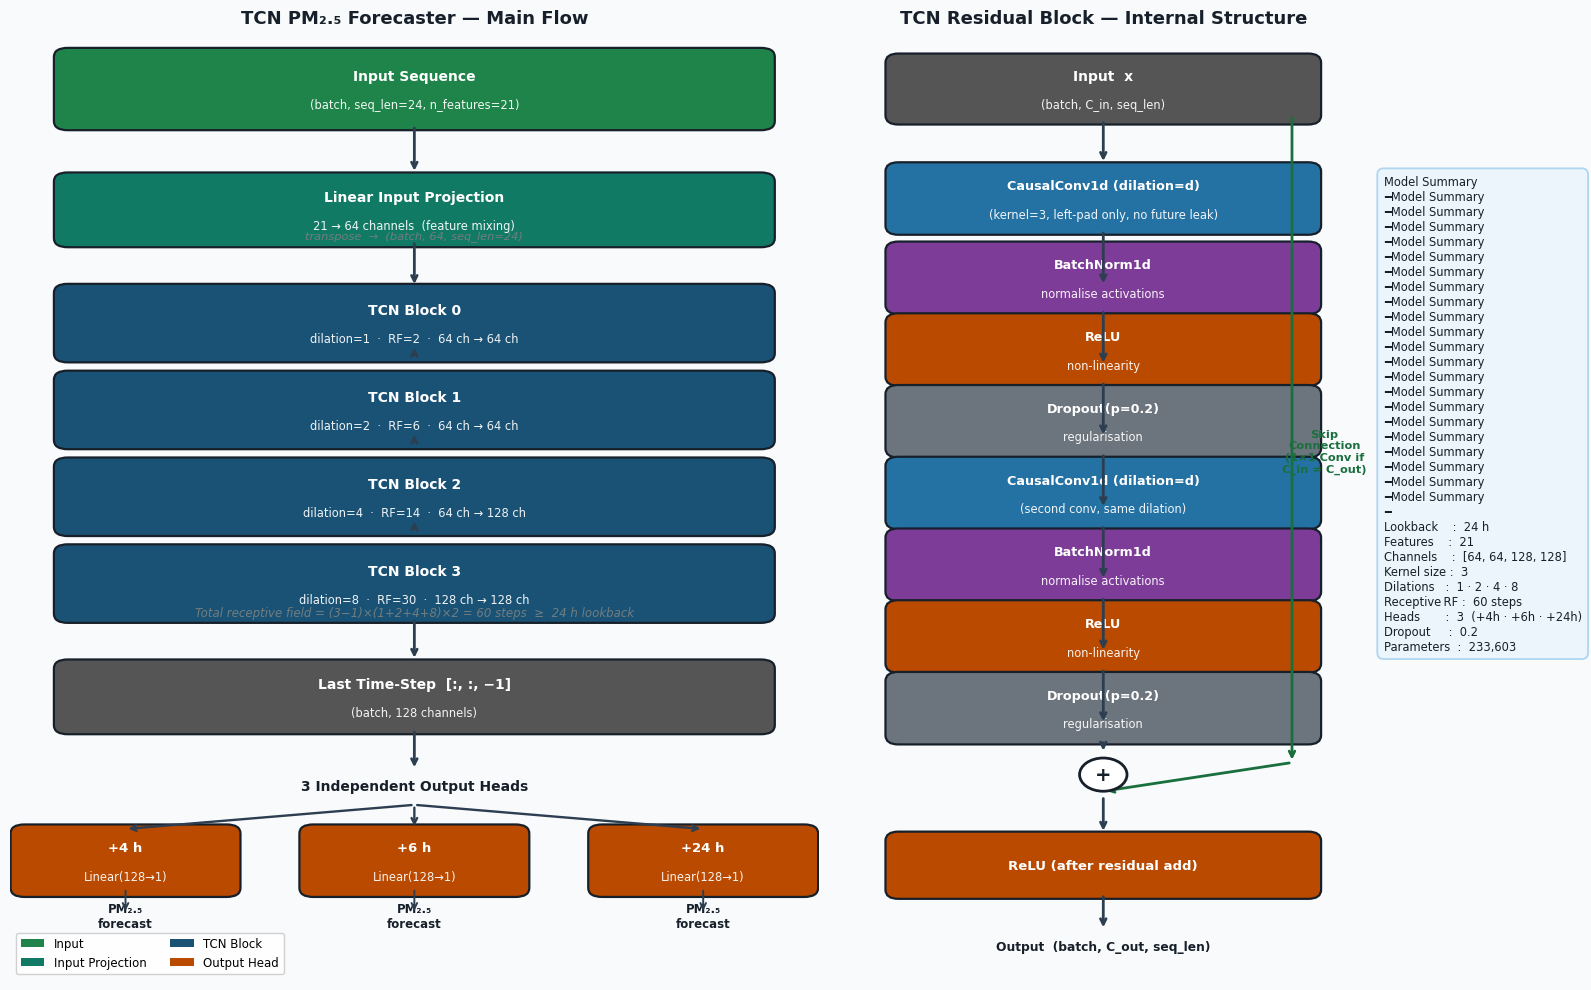

Saved → ../figures/tcn_architecture.png


In [27]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, (ax_main, ax_block) = plt.subplots(1, 2, figsize=(16, 10),
                                          gridspec_kw={'width_ratios': [3, 2]})
for ax in (ax_main, ax_block):
    ax.axis('off')
fig.patch.set_facecolor('#F8FAFC')

C = dict(inp='#1E8449', proj='#117A65', blk='#1A5276', head='#BA4A00',
         conv='#2471A3', norm='#7D3C98', act='#BA4A00', skip='#196F3D',
         text='#17202A', muted='#717D7E', arrow='#2C3E50')

# ─── helpers ──────────────────────────────────────────────────────────────────
def fbox(ax, cx, cy, w, h, title, sub='', color='#1A5276', ts=10):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h, zorder=3,
                        boxstyle='round,pad=0.12', fc=color, ec='#17202A', lw=1.6)
    ax.add_patch(p)
    dy = 0.17 if sub else 0
    ax.text(cx, cy+dy, title, ha='center', va='center', fontsize=ts,
            fontweight='bold', color='white', zorder=4)
    if sub:
        ax.text(cx, cy-0.21, sub, ha='center', va='center',
                fontsize=8.3, color='white', alpha=0.93, zorder=4)

def varr(ax, x, y1, y2, color='#2C3E50'):
    ax.annotate('', xy=(x, y2+0.06), xytext=(x, y1-0.06),
                arrowprops=dict(arrowstyle='->', lw=2.0, color=color), zorder=5)

# ─── MAIN FLOW PANEL ──────────────────────────────────────────────────────────
ax_main.set_xlim(0, 7); ax_main.set_ylim(0, 12.5)

CX = 3.5

fbox(ax_main, CX, 11.8, 6.0, 0.85,
     'Input Sequence', '(batch, seq_len=24, n_features=21)', C['inp'])
varr(ax_main, CX, 11.38, 10.62)

fbox(ax_main, CX, 10.2, 6.0, 0.75,
     'Linear Input Projection', '21 \u2192 64 channels  (feature mixing)', C['proj'])
ax_main.text(CX, 9.82, 'transpose  \u2192  (batch, 64, seq_len=24)',
             ha='center', fontsize=8.2, color=C['muted'], style='italic')
varr(ax_main, CX, 9.85, 9.12)

# TCN blocks
block_info = [
    ('TCN Block 0', 'dilation=1  \u00b7  RF=2  \u00b7  64 ch \u2192 64 ch',  8.70, C['blk']),
    ('TCN Block 1', 'dilation=2  \u00b7  RF=6  \u00b7  64 ch \u2192 64 ch',  7.55, C['blk']),
    ('TCN Block 2', 'dilation=4  \u00b7  RF=14  \u00b7  64 ch \u2192 128 ch', 6.40, C['blk']),
    ('TCN Block 3', 'dilation=8  \u00b7  RF=30  \u00b7  128 ch \u2192 128 ch',5.25, C['blk']),
]
for title, sub, cy, color in block_info:
    fbox(ax_main, CX, cy, 6.0, 0.80, title, sub, color)
    if cy > 5.25:
        varr(ax_main, CX, cy-0.40, cy-1.15+0.80)

ax_main.text(CX, 4.82,
    'Total receptive field = (3\u22121)\u00d7(1+2+4+8)\u00d72 = 60 steps  \u2265  24 h lookback',
    ha='center', fontsize=8.5, color=C['muted'], style='italic')
varr(ax_main, CX, 4.85, 4.17)

fbox(ax_main, CX, 3.75, 6.0, 0.75,
     'Last Time-Step  [:, :, \u22121]', '(batch, 128 channels)', '#555555')
varr(ax_main, CX, 3.38, 2.72)

ax_main.text(CX, 2.52, '3 Independent Output Heads',
             ha='center', fontsize=10, fontweight='bold', color=C['text'])

HEAD_XS = [1.0, 3.5, 6.0]
for hx in HEAD_XS:
    ax_main.annotate('', xy=(hx, 2.00), xytext=(CX, 2.32),
                     arrowprops=dict(arrowstyle='->', lw=1.7, color=C['arrow']), zorder=5)
for hx, lbl in zip(HEAD_XS, ['+4 h', '+6 h', '+24 h']):
    fbox(ax_main, hx, 1.58, 1.75, 0.72, lbl, 'Linear(128\u21921)', C['head'], ts=9.5)
    ax_main.annotate('', xy=(hx, 0.88), xytext=(hx, 1.22),
                     arrowprops=dict(arrowstyle='->', lw=1.4, color=C['arrow']), zorder=5)
    ax_main.text(hx, 0.70, 'PM\u2082.\u2085\nforecast', ha='center',
                 fontsize=8.5, color=C['text'], fontweight='bold')

ax_main.legend(handles=[
    mpatches.Patch(fc=C['inp'],  label='Input'),
    mpatches.Patch(fc=C['proj'], label='Input Projection'),
    mpatches.Patch(fc=C['blk'],  label='TCN Block'),
    mpatches.Patch(fc=C['head'], label='Output Head'),
], loc='lower left', fontsize=8.5, framealpha=0.9, edgecolor='#ccc', ncol=2)

ax_main.set_title('TCN PM\u2082.\u2085 Forecaster \u2014 Main Flow',
                  fontsize=13, fontweight='bold', color=C['text'], y=1.005)

# ─── TCN BLOCK DETAIL PANEL ───────────────────────────────────────────────────
ax_block.set_xlim(0, 5); ax_block.set_ylim(0, 12.5)

BX = 2.5

ax_block.set_title('TCN Residual Block \u2014 Internal Structure',
                   fontsize=13, fontweight='bold', color=C['text'], y=1.005)

# Input
fbox(ax_block, BX, 11.8, 3.8, 0.70, 'Input  x', '(batch, C_in, seq_len)', '#555')
varr(ax_block, BX, 11.45, 10.75)

# Conv path
layers = [
    ('CausalConv1d (dilation=d)',  '(kernel=3, left-pad only, no future leak)', C['conv'], 10.35),
    ('BatchNorm1d',                'normalise activations',                      C['norm'],  9.30),
    ('ReLU',                       'non-linearity',                              C['act'],   8.35),
    ('Dropout(p=0.2)',             'regularisation',                             '#6c757d',  7.40),
    ('CausalConv1d (dilation=d)',  '(second conv, same dilation)',               C['conv'],  6.45),
    ('BatchNorm1d',                'normalise activations',                      C['norm'],  5.50),
    ('ReLU',                       'non-linearity',                              C['act'],   4.55),
    ('Dropout(p=0.2)',             'regularisation',                             '#6c757d',  3.60),
]
for title, sub, color, cy in layers:
    fbox(ax_block, BX, cy, 3.8, 0.72, title, sub, color, ts=9.2)
    if cy > 3.60:
        varr(ax_block, BX, cy-0.36, cy-1.22)

# Skip connection (right side)
ax_block.annotate('', xy=(4.25, 2.88), xytext=(4.25, 11.45),
                  arrowprops=dict(arrowstyle='->', lw=2.0, color=C['skip'],
                                  connectionstyle='arc3,rad=0.0'), zorder=5)
ax_block.text(4.55, 7.0, 'Skip\nConnection\n(1\u00d71 Conv if\nC_in \u2260 C_out)',
              ha='center', va='center', fontsize=8.2, color=C['skip'],
              fontweight='bold')

# Add (+) node
circle = plt.Circle((BX, 2.72), 0.22, fc='white', ec=C['text'], lw=2, zorder=6)
ax_block.add_patch(circle)
ax_block.text(BX, 2.72, '+', ha='center', va='center', fontsize=14,
              fontweight='bold', color=C['text'], zorder=7)
ax_block.annotate('', xy=(BX, 2.50), xytext=(4.25, 2.88),
                  arrowprops=dict(arrowstyle='->', lw=2.0, color=C['skip']), zorder=5)
varr(ax_block, BX, 3.24, 2.94)
varr(ax_block, BX, 2.50, 1.88)

fbox(ax_block, BX, 1.52, 3.8, 0.65, 'ReLU (after residual add)', '', C['act'], ts=9.5)
varr(ax_block, BX, 1.20, 0.60)
ax_block.text(BX, 0.40, 'Output  (batch, C_out, seq_len)',
              ha='center', fontsize=8.8, color=C['text'], fontweight='bold')

# Summary
total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
summary = (
    "Model Summary\n"
    "\u2501" * 22 + "\n"
    f"Lookback    :  24 h\n"
    f"Features    :  {N_FEATURES}\n"
    "Channels    :  [64, 64, 128, 128]\n"
    "Kernel size :  3\n"
    "Dilations   :  1 \u00b7 2 \u00b7 4 \u00b7 8\n"
    "Receptive\u2009RF :  60 steps\n"
    "Heads       :  3  (+4h \u00b7 +6h \u00b7 +24h)\n"
    "Dropout     :  0.2\n"
    f"Parameters  :  {total_p:,}"
)
ax_block.text(5.1, 7.5, summary, fontsize=8.3, va='center', ha='left',
              color=C['text'], clip_on=False,
              bbox=dict(boxstyle='round,pad=0.55', fc='#EBF5FB', ec='#AED6F1', lw=1.3))

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/tcn_architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved \u2192 ../figures/tcn_architecture.png')

## 6  —  Training Loop

In [20]:
EPOCHS          = 60
LEARNING_RATE   = 1e-3
PATIENCE        = 8
MODEL_SAVE_PATH = '../models/tcn/tcn_pm25_best.pt'

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4
)


def run_epoch(loader, train: bool) -> float:
    model.train() if train else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            if train:
                optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


train_losses, val_losses = [], []
best_val_loss    = float('inf')
patience_counter = 0

print(f'Training on {DEVICE}  |  epochs={EPOCHS}  |  batch={BATCH_SIZE}  |  lr={LEARNING_RATE}')
print('─' * 65)

train_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()
    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    epoch_time = time.perf_counter() - epoch_start
    print(f'Epoch {epoch:>3}/{EPOCHS}  |  '
          f'Train MSE: {tr_loss:.5f}  |  '
          f'Val MSE: {val_loss:.5f}  |  '
          f'{epoch_time:.1f}s')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch'              : epoch,
            'model_state_dict'   : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss'           : best_val_loss,
            'model_config'       : {
                'input_size'  : N_FEATURES,
                'num_channels': [64, 64, 128, 128],
                'kernel_size' : 3,
                'dropout'     : 0.2,
                'n_horizons'  : len(HORIZONS),
            },
            'feature_names'      : ALL_FEATURES,
            'horizons'           : HORIZONS,
            'feat_scaler_mean'   : feat_scaler.mean_,
            'feat_scaler_scale'  : feat_scaler.scale_,
            'target_scaler_mean' : target_scaler.mean_,
            'target_scaler_scale': target_scaler.scale_,
        }, MODEL_SAVE_PATH)
        print(f'  ✓ New best model saved (val MSE = {best_val_loss:.5f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping after {epoch} epochs.')
            break

total_train_time = time.perf_counter() - train_start
print('─' * 65)
print(f'Total training time : {total_train_time:.1f}s  ({total_train_time/60:.2f} min)')
print(f'Best validation MSE : {best_val_loss:.5f}')
print(f'Model saved to      : {MODEL_SAVE_PATH}')

Training on mps  |  epochs=60  |  batch=128  |  lr=0.001
─────────────────────────────────────────────────────────────────
Epoch   1/60  |  Train MSE: 0.92011  |  Val MSE: 0.67181  |  7.2s
  ✓ New best model saved (val MSE = 0.67181)
Epoch   2/60  |  Train MSE: 0.73923  |  Val MSE: 0.63282  |  7.1s
  ✓ New best model saved (val MSE = 0.63282)
Epoch   3/60  |  Train MSE: 0.68635  |  Val MSE: 0.66588  |  8.7s
Epoch   4/60  |  Train MSE: 0.62242  |  Val MSE: 0.71486  |  7.9s
Epoch   5/60  |  Train MSE: 0.57166  |  Val MSE: 0.71081  |  8.3s
Epoch   6/60  |  Train MSE: 0.52744  |  Val MSE: 0.74047  |  11.7s
Epoch   7/60  |  Train MSE: 0.49604  |  Val MSE: 0.69243  |  12.8s
Epoch   8/60  |  Train MSE: 0.43769  |  Val MSE: 0.69669  |  11.1s
Epoch   9/60  |  Train MSE: 0.42208  |  Val MSE: 0.71273  |  11.0s
Epoch  10/60  |  Train MSE: 0.40517  |  Val MSE: 0.69012  |  10.6s

Early stopping after 10 epochs.
─────────────────────────────────────────────────────────────────
Total training time : 9

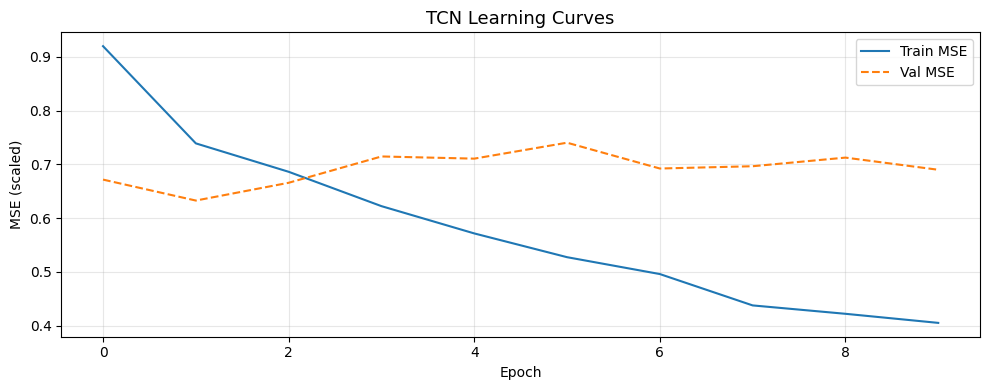

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train MSE', linewidth=1.5)
ax.plot(val_losses,   label='Val MSE',   linewidth=1.5, linestyle='--')
ax.set_title('TCN Learning Curves', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7  —  Evaluation (RMSE, MAE, R² per Horizon)

In [22]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint: epoch {checkpoint['epoch']}, ",
      f"val MSE = {checkpoint['val_loss']:.5f}")


def predict_all(loader):
    """Return (preds, targets) in original ppb scale.""",
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds_list.append(model(X_batch.to(DEVICE)).cpu().numpy())
            targets_list.append(y_batch.numpy())
    preds   = target_scaler.inverse_transform(np.vstack(preds_list))
    targets = target_scaler.inverse_transform(np.vstack(targets_list))
    return preds, targets


test_preds, test_targets = predict_all(test_loader)

print(f'\n{" Horizon ":^12} | {"RMSE (ppb)":^12} | {"MAE (ppb)":^12} | {"R²":^8}')
print('─' * 52)
metrics_dict = {}
for i, h in enumerate(HORIZONS):
    y_true = test_targets[:, i]
    y_pred = test_preds[:,  i]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    metrics_dict[h] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'  +{h:>2}h ahead   | {rmse:^12.3f} | {mae:^12.3f} | {r2:^8.4f}')

Loaded best checkpoint: epoch 2,  val MSE = 0.63282

  Horizon    |  RMSE (ppb)  |  MAE (ppb)   |    R²   
────────────────────────────────────────────────────
  + 4h ahead   |    10.232    |    6.256     |  0.1035 
  + 6h ahead   |    10.283    |    6.303     |  0.0945 
  +24h ahead   |    10.559    |    6.538     |  0.0451 


## 8  —  Save & Load Model

In [23]:
def save_model(model, path, extra_meta=None):
    payload = {'model_state_dict': model.state_dict()}
    if extra_meta:
        payload.update(extra_meta)
    torch.save(payload, path)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f'Model saved → {path}  ({size_mb:.2f} MB)')


def load_model(path, device=torch.device('cpu')):
    """
    Reconstruct a PM25TCNForecaster from a saved checkpoint.
    Returns (model, checkpoint_dict).
    """
    ckpt = torch.load(path, map_location=device, weights_only=False)
    cfg  = ckpt['model_config']
    m = PM25TCNForecaster(
        input_size   = cfg['input_size'],
        num_channels = cfg['num_channels'],
        kernel_size  = cfg['kernel_size'],
        dropout      = cfg['dropout'],
        n_horizons   = cfg['n_horizons'],
    ).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    print(f'Loaded → {path}')
    print(f'  Epoch {ckpt["epoch"]}  |  val MSE = {ckpt["val_loss"]:.5f}')
    print(f'  Features : {ckpt["feature_names"]}')
    print(f'  Horizons : {ckpt["horizons"]} h')
    return m, ckpt


EXPORT_PATH = '../models/tcn/tcn_pm25_final.pt'
save_model(
    model, EXPORT_PATH,
    extra_meta={
        'model_config'       : checkpoint['model_config'],
        'epoch'              : checkpoint['epoch'],
        'val_loss'           : checkpoint['val_loss'],
        'feature_names'      : ALL_FEATURES,
        'horizons'           : HORIZONS,
        'feat_scaler_mean'   : feat_scaler.mean_,
        'feat_scaler_scale'  : feat_scaler.scale_,
        'target_scaler_mean' : target_scaler.mean_,
        'target_scaler_scale': target_scaler.scale_,
    }
)

print('\n--- Reload demo ---')
reloaded_model, _ = load_model(EXPORT_PATH, device=DEVICE)

Model saved → ../models/tcn/tcn_pm25_final.pt  (0.92 MB)

--- Reload demo ---
Loaded → ../models/tcn/tcn_pm25_final.pt
  Epoch 2  |  val MSE = 0.63282
  Features : ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Hmdx', 'Wind Chill', 'is_fog', 'is_rain', 'is_snow', 'is_drizzle', 'is_thunderstorm', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
  Horizons : [4, 6, 24] h


## 9  —  Visualisation

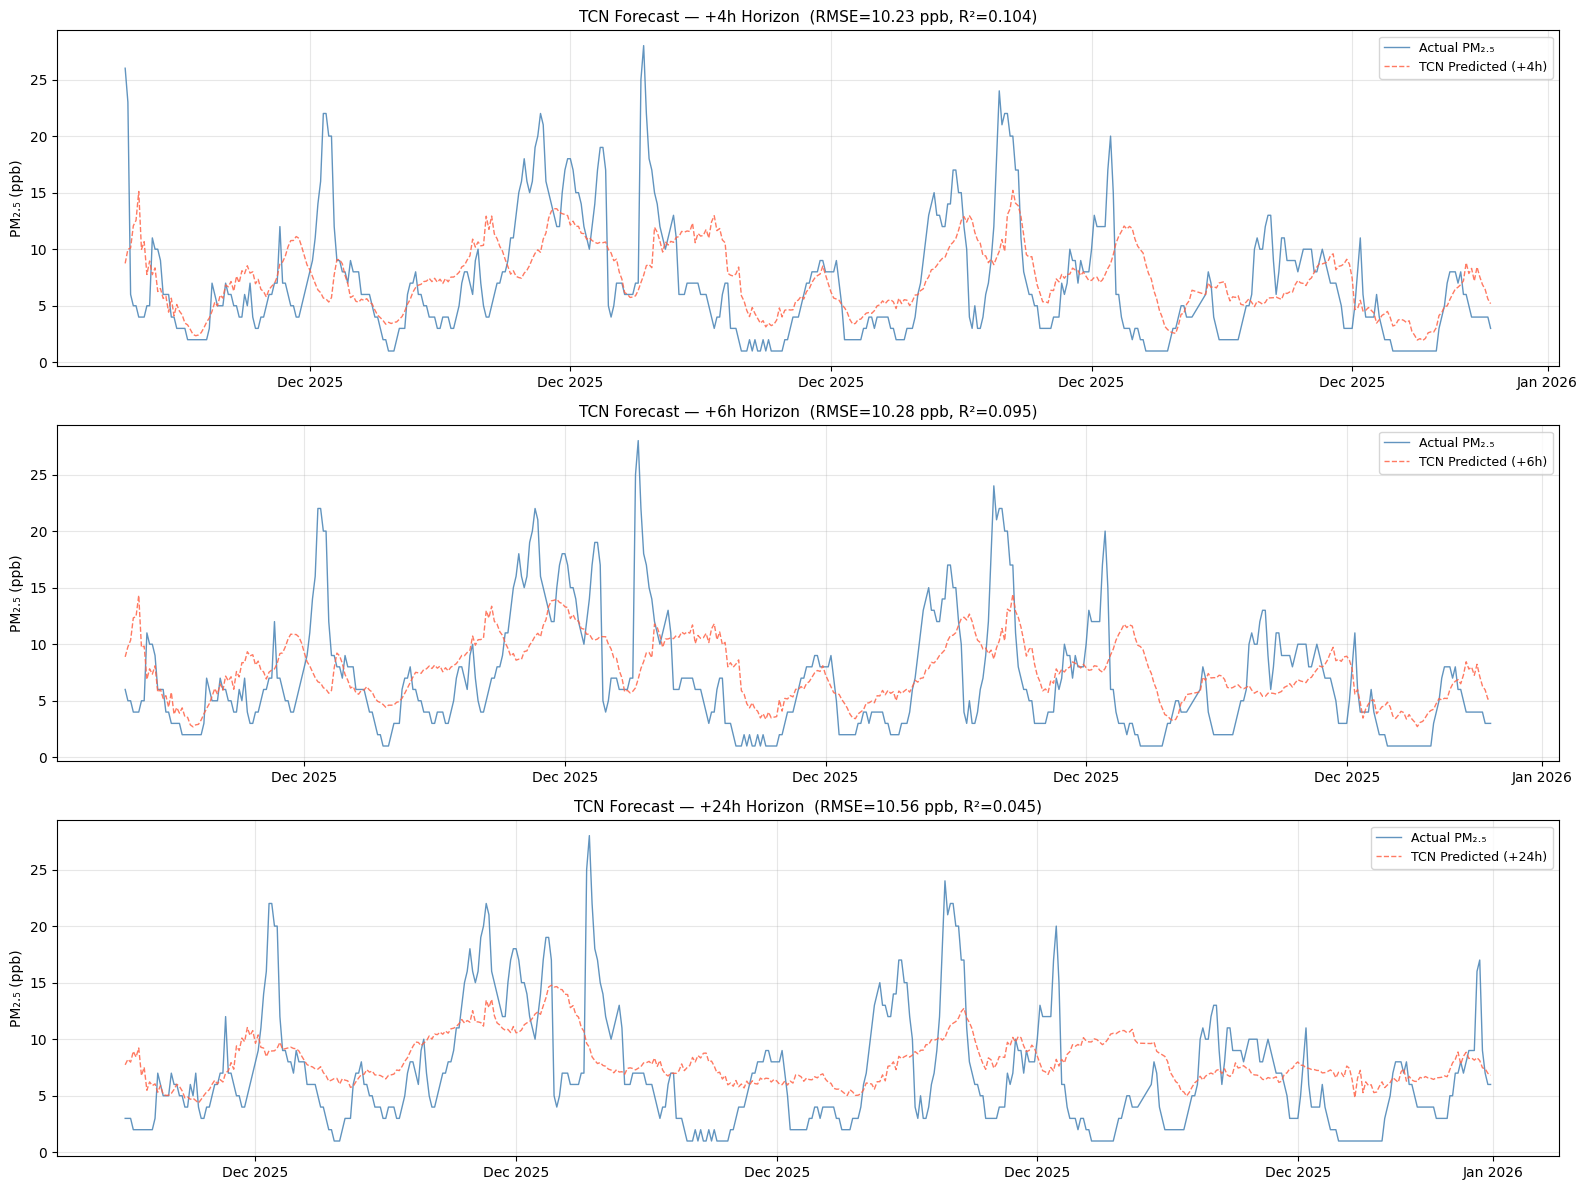

In [24]:
test_df_reset  = test_df.reset_index(drop=True)
n_test_samples = len(test_ds)
PLOT_WINDOW    = 500

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(16, 12), sharex=False)

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    date_idx = [idx + LOOKBACK + h - 1 for idx in range(n_test_samples)]
    dates    = pd.to_datetime(test_df_reset.iloc[date_idx]['Datetime'].values)[-PLOT_WINDOW:]
    actual   = test_targets[:, i][-PLOT_WINDOW:]
    pred     = test_preds[:,  i][-PLOT_WINDOW:]
    ax.plot(dates, actual, label='Actual PM₂.₅',
            linewidth=1.0, color='steelblue', alpha=0.85)
    ax.plot(dates, pred,   label=f'TCN Predicted (+{h}h)',
            linewidth=1.0, color='tomato', linestyle='--', alpha=0.85)
    ax.set_title(f'TCN Forecast — +{h}h Horizon  '
                 f'(RMSE={metrics_dict[h]["RMSE"]:.2f} ppb, '
                 f'R²={metrics_dict[h]["R2"]:.3f})', fontsize=11)
    ax.set_ylabel('PM₂.₅ (ppb)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

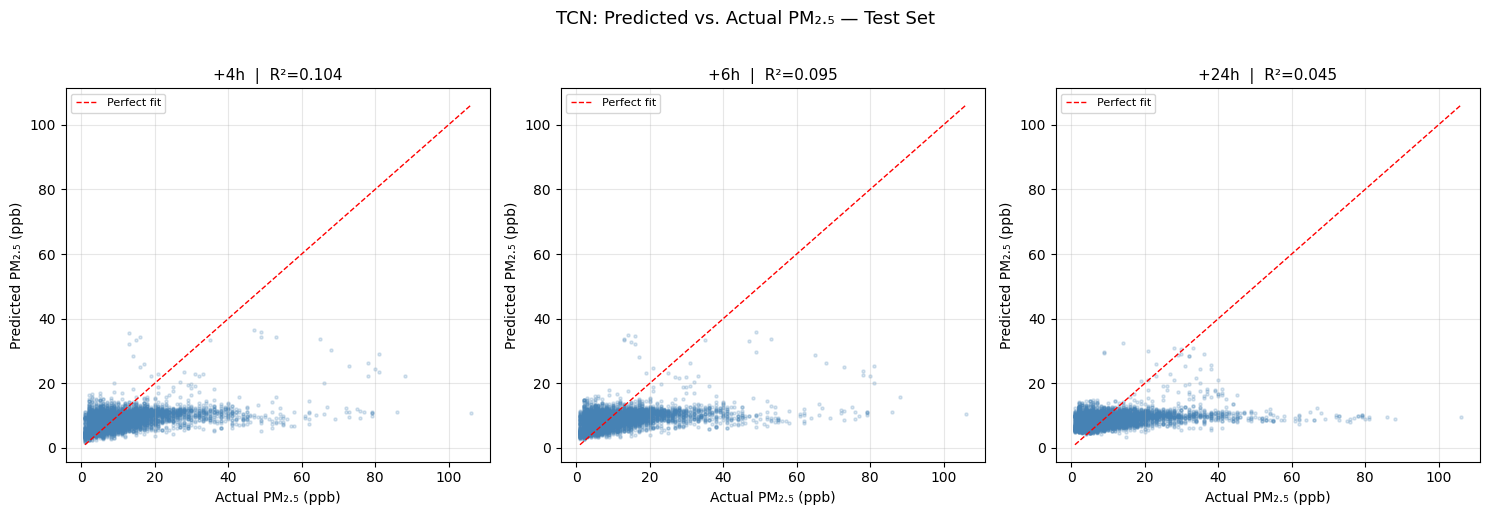

In [25]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 5))

for i, h in enumerate(HORIZONS):
    ax     = axes[i]
    y_true = test_targets[:, i]
    y_pred = test_preds[:,  i]
    ax.scatter(y_true, y_pred, alpha=0.2, s=5, color='steelblue')
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect fit')
    ax.set_title(f'+{h}h  |  R²={metrics_dict[h]["R2"]:.3f}', fontsize=11)
    ax.set_xlabel('Actual PM₂.₅ (ppb)')
    ax.set_ylabel('Predicted PM₂.₅ (ppb)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('TCN: Predicted vs. Actual PM₂.₅ — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
summary = pd.DataFrame([
    {'Horizon': f'+{h}h', 'RMSE (ppb)': metrics_dict[h]['RMSE'],
     'MAE (ppb)': metrics_dict[h]['MAE'], 'R²': metrics_dict[h]['R2']}
    for h in HORIZONS
]).set_index('Horizon').round(4)

print('\n=== TCN — Final Test-Set Performance Summary ===')
display(summary)


=== TCN — Final Test-Set Performance Summary ===


,RMSE (ppb),MAE (ppb),R²
Horizon,,,
+4h,10.2321,6.2562,0.1035
+6h,10.2831,6.3027,0.0945
+24h,10.5594,6.5375,0.0451
